# Model Performance Analysis
Analyze screening accuracy and fit statistics from Promptfoo evaluation results.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set Seaborn theme once
sns.set_theme(style="ticks")

# Load evaluation results CSV dynamically (finding the most recent eval_results_for_*_models.csv file)
tmp_dir = Path("../tmp/promptfoo")
csv_files = sorted(tmp_dir.glob("eval_results_for_*_models.csv"), key=lambda p: p.stat().st_mtime, reverse=True)
results_path = csv_files[0] if csv_files else tmp_dir / "eval_results.csv"

df = pd.read_csv(results_path)

# Define consistent color palette for models dynamically supporting any number of models
unique_models = sorted(df["Model"].unique())
base_colors = sns.color_palette("muted", len(unique_models)).as_hex()
model_palette = {model: base_colors[i] for i, model in enumerate(unique_models)}

df.head(10)

,Model,Job Description,Success,Latency (s),Prompt Tokens,Completion Tokens,Total Tokens,Failure Reason
0,deepseek-r1:1.5b,contract,FAIL,19.590,2521,1291,3812,Failed to parse LLM output as JSON: Expecting ...
1,qwen2.5:3b-instruct-q8_0,contract,FAIL,12.743,2547,159,2706,Failed to parse LLM output as JSON: Expecting ...
2,deepseek-r1:7b,contract,FAIL,79.416,2521,1073,3594,Failed to parse LLM output as JSON: Expecting ...
3,qwen2.5:7b,contract,FAIL,20.036,2547,151,2698,Failed to parse LLM output as JSON: Expecting ...
4,qwen2.5-coder:7b,contract,FAIL,21.089,2547,169,2716,Failed to parse LLM output as JSON: Expecting ...
5,codegemma:7b-code,contract,FAIL,12.385,2507,2,2509,Empty output received from LLM.
6,mistral:7b-instruct-v0.3-q4_K_M,contract,FAIL,24.104,3030,201,3231,Failed to parse LLM output as JSON: Expecting ...
7,qwen2.5:7b-instruct-q4_K_M,contract,FAIL,16.104,2547,151,2698,Failed to parse LLM output as JSON: Expecting ...
8,llama3.1:8b,contract,FAIL,22.837,2398,152,2550,Failed to parse LLM output as JSON: Expecting ...
9,llama3.1:8b-instruct-q6_K,contract,FAIL,25.490,2398,164,2562,Failed to parse LLM output as JSON: Expecting ...


In [2]:
# Generate summary table: Pass, Fail, Total, Success Rate (%)
summary = df.groupby("Model")["Success"].value_counts().unstack().fillna(0).astype(int)  # noqa: PD010
if "PASS" not in summary.columns:
    summary["PASS"] = 0
if "FAIL" not in summary.columns:
    summary["FAIL"] = 0

summary["Total"] = summary["PASS"] + summary["FAIL"]
summary["Success Rate (%)"] = (summary["PASS"] / summary["Total"] * 100).round(1)

# Reorder columns for clean presentation
summary = summary[["PASS", "FAIL", "Total", "Success Rate (%)"]].sort_values(["Success Rate (%)"])
display(summary)

Success,PASS,FAIL,Total,Success Rate (%)
Model,,,,
codegemma:7b-code,0,8,8,0.0
deepseek-r1:1.5b,0,8,8,0.0
deepseek-r1:7b,0,8,8,0.0
gemma2:9b-instruct-q5_K_M,0,8,8,0.0
qwen2.5-coder:7b,0,8,8,0.0
qwen2.5:3b-instruct-q8_0,0,8,8,0.0
qwen2.5:7b,0,8,8,0.0
llama3.1:8b-text-q4_K_M,0,8,8,0.0
qwen3.5:9b-q4_K_M,0,8,8,0.0


## Model Screening Results


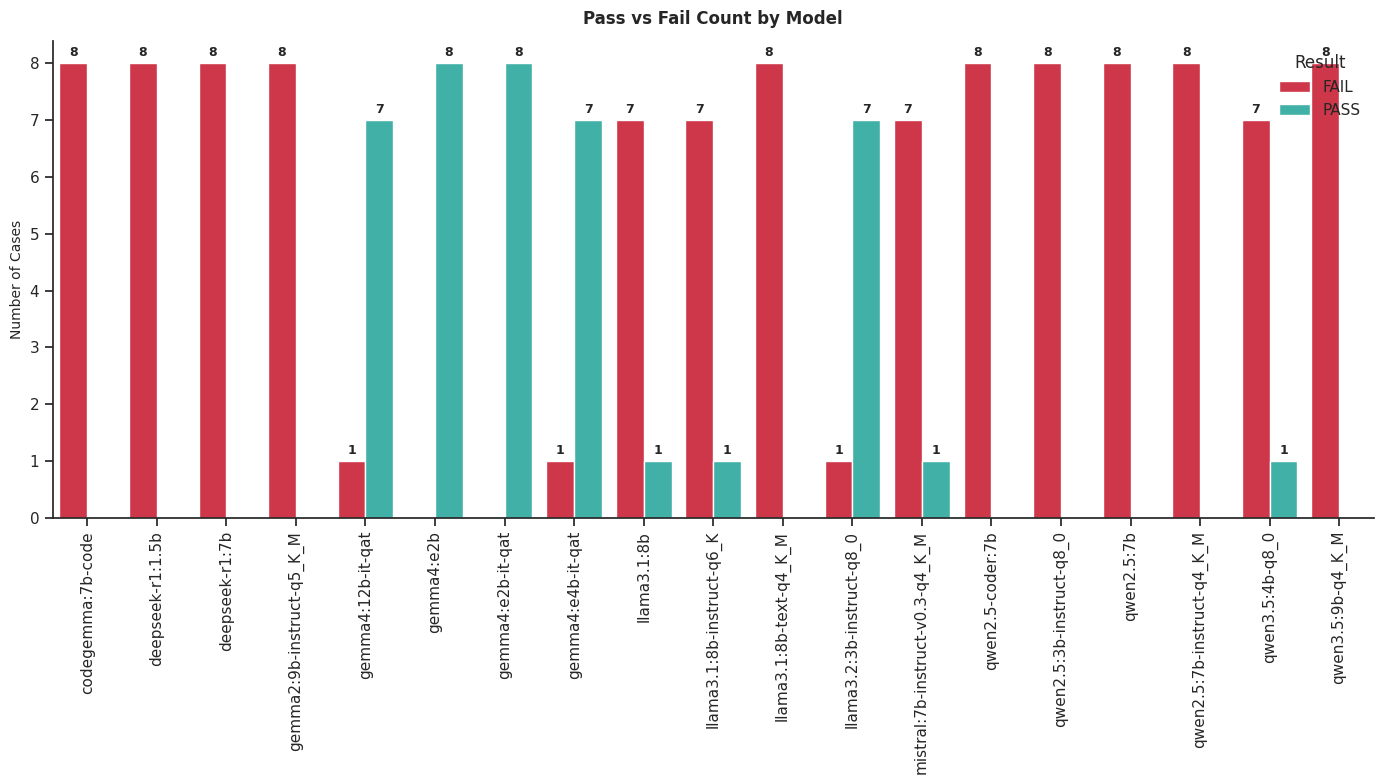

In [3]:
# Plot pass vs fail using Seaborn countplot
plt.figure(figsize=(14, 8))
ax = sns.countplot(
    data=df,
    x="Model",
    order=unique_models,
    hue="Success",
    palette={"PASS": "#2ec4b6", "FAIL": "#e71d36"}
)

plt.title("Pass vs Fail Count by Model", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("")
plt.ylabel("Number of Cases", fontsize=10)
plt.xticks(rotation=90, ha="center")
plt.legend(title="Result", frameon=False, loc="upper right")
sns.despine()

# Add value labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{int(height)}",
                    xy=(p.get_x() + p.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

## Completion Tokens per Job Description


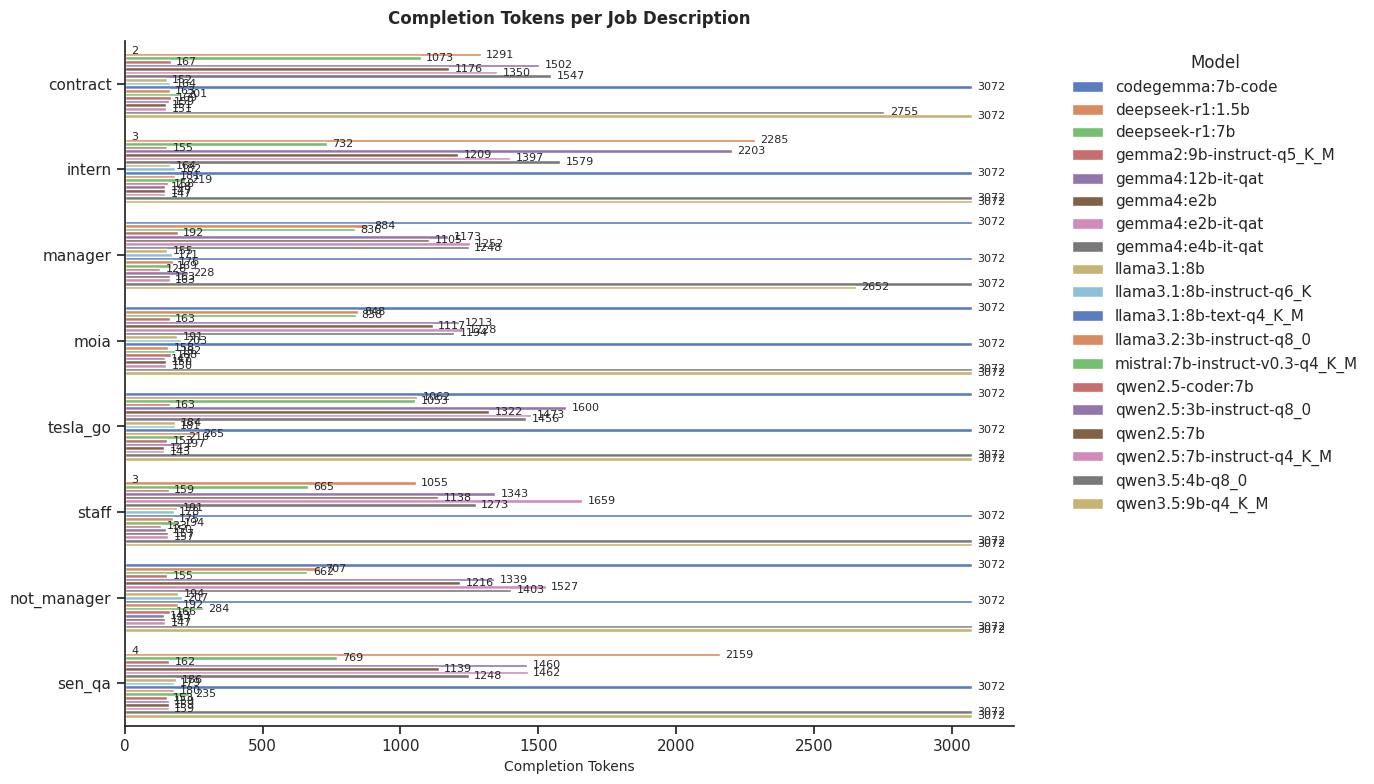

In [4]:
# Plot Completion Tokens per Job Description (Horizontal Bar Chart)
plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=df,
    y="Job Description",
    x="Completion Tokens",
    hue="Model",
    hue_order=unique_models,
    palette=model_palette
)
plt.title("Completion Tokens per Job Description", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Completion Tokens", fontsize=10)
plt.ylabel("")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)
sns.despine()

# Add value labels at the end of the bars
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f"{int(width)}",
                    xy=(width, p.get_y() + p.get_height() / 2),
                    xytext=(4, 0),  # 4 points horizontal offset
                    textcoords="offset points",
                    ha="left", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## Average Completion Tokens by Model


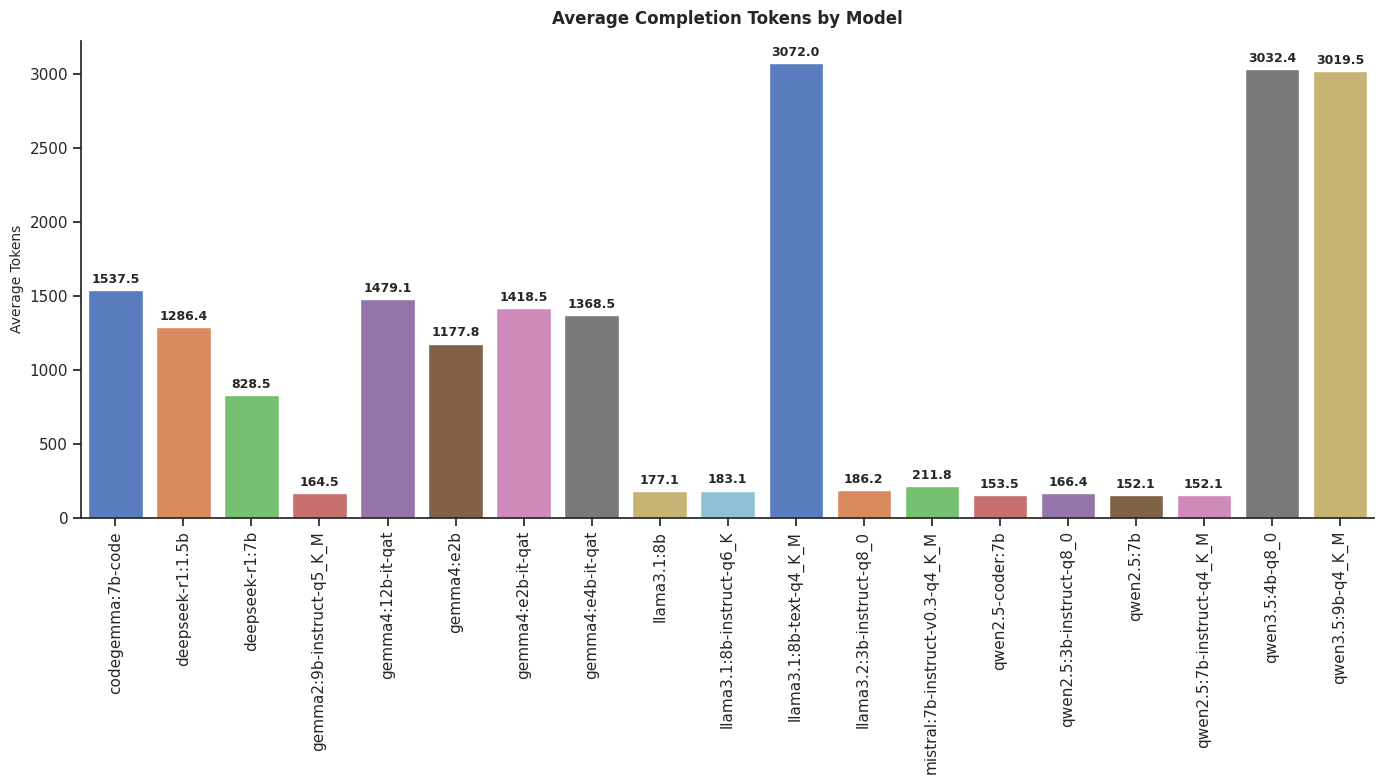

In [5]:
# Plot Average Completion Tokens by Model
plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=df,
    x="Model",
    y="Completion Tokens",
    hue="Model",
    order=unique_models,
    hue_order=unique_models,
    palette=model_palette,
    legend=False,
    estimator="mean",
    errorbar=None
)
plt.title("Average Completion Tokens by Model", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("")
plt.ylabel("Average Tokens", fontsize=10)
plt.xticks(rotation=90, ha="center")
sns.despine()

# Add labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{height:.1f}",
                    xy=(p.get_x() + p.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

## Completion Tokens per Model


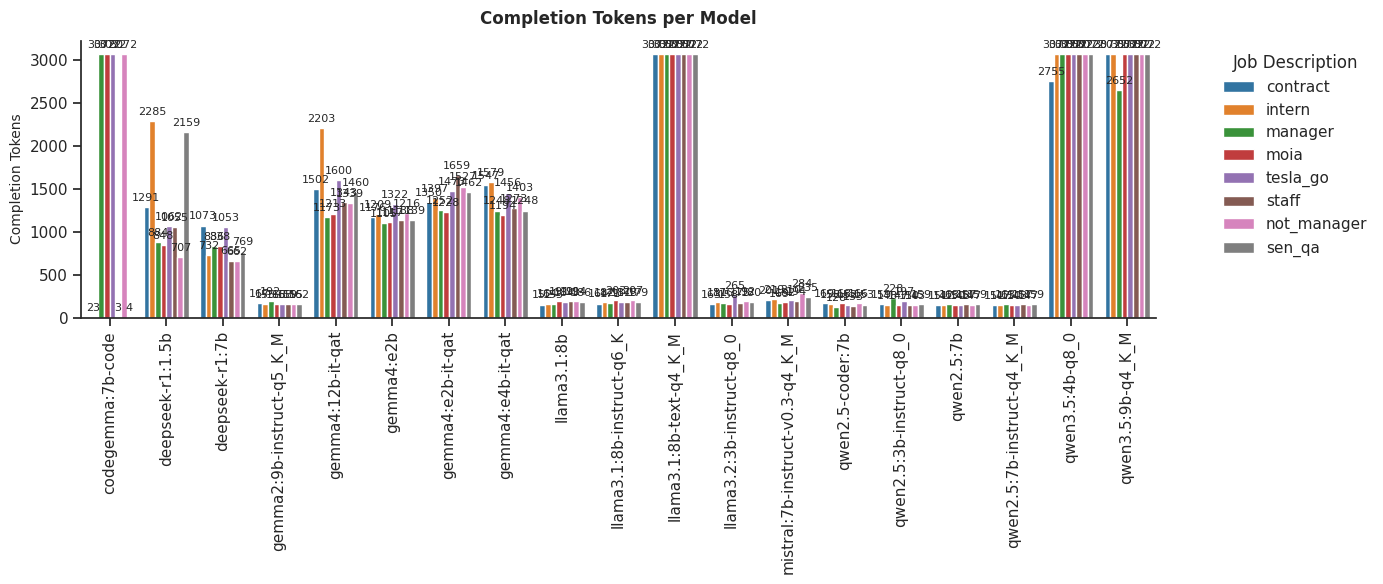

In [6]:
# Plot Completion Tokens per Model
plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=df,
    x="Model",
    y="Completion Tokens",
    order=unique_models,
    hue="Job Description",
    palette="tab10",
    errorbar=None
)
plt.title("Completion Tokens per Model", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("")
plt.ylabel("Completion Tokens", fontsize=10)
plt.xticks(rotation=90, ha="center")
plt.legend(title="Job Description", bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)
sns.despine()

# Add value labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{int(height)}",
                    xy=(p.get_x() + p.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

## Average Latency for PASSED Cases


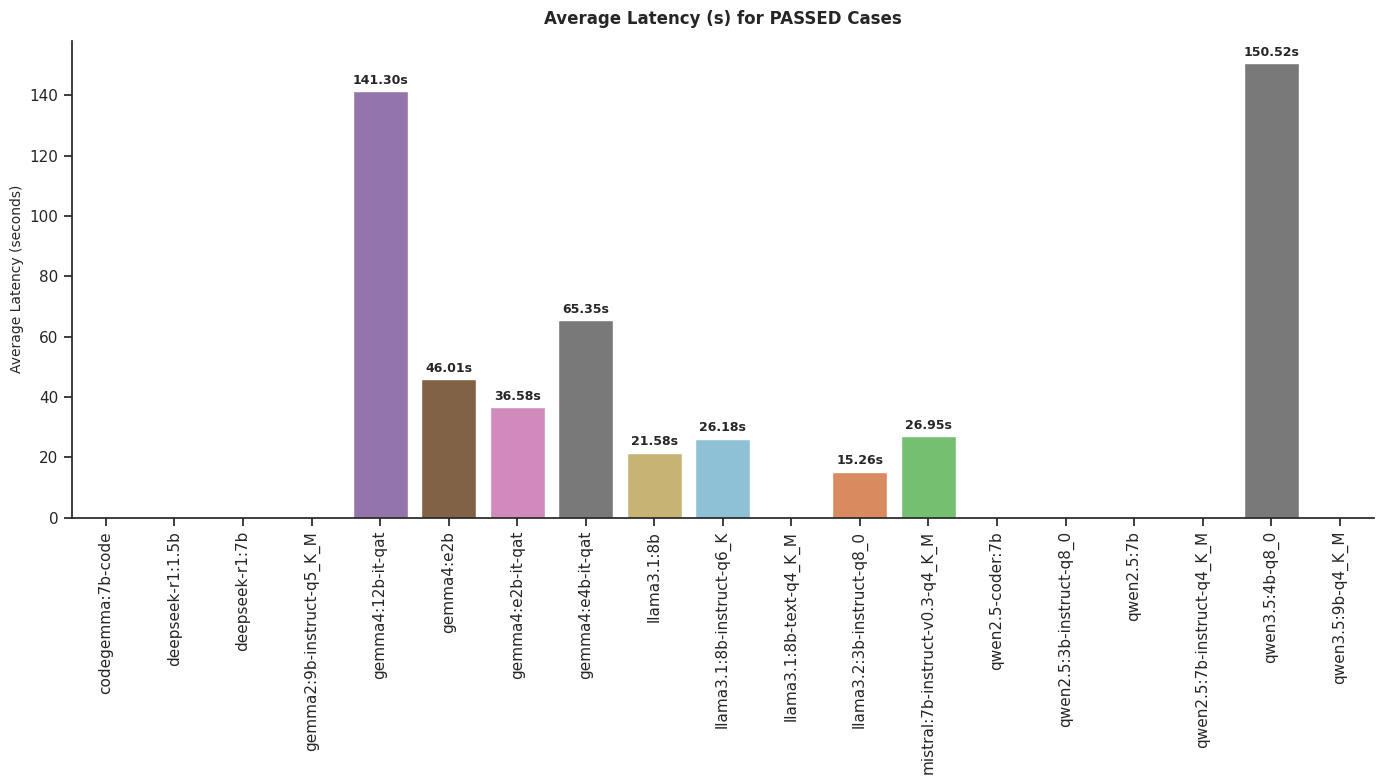

In [7]:
# Filter to only PASSED cases
passed_df = df[df["Success"] == "PASS"]

plt.figure(figsize=(14, 8))
if not passed_df.empty:
    ax = sns.barplot(
        data=passed_df,
        x="Model",
        order=unique_models,
        hue_order=unique_models,
        y="Latency (s)",
        hue="Model",
        palette=model_palette,
        legend=False,
        estimator="mean",
        errorbar=None
    )
    plt.title("Average Latency (s) for PASSED Cases", fontsize=12, fontweight="bold", pad=12)
    plt.xlabel("")
    plt.ylabel("Average Latency (seconds)", fontsize=10)
    plt.xticks(rotation=90, ha="center")
    sns.despine()

    # Add value labels on top of the bars
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f"{height:.2f}s",
                        xy=(p.get_x() + p.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha="center", va="bottom", fontsize=9, fontweight="bold")
else:
    plt.text(0.5, 0.5, "No PASSED cases found to calculate latency.",
             horizontalalignment="center", verticalalignment="center", fontsize=10)
    plt.title("Average Latency for PASSED Cases (No Data)", fontsize=12, fontweight="bold", pad=12)
    sns.despine()

plt.tight_layout()
plt.show()

# Print model performance analysis table for Success Rate >= 50%


In [8]:
avg_tokens = df.groupby("Model")["Completion Tokens"].mean().round(1)
avg_latency = passed_df.groupby("Model")["Latency (s)"].mean().round(2)

analysis_tbl = summary.copy()
analysis_tbl["Average Completion Tokens"] = avg_tokens
analysis_tbl["Average Latency (s)"] = avg_latency

# Filter and sort
MIN_SUCCESS_RATE = 50
filtered_tbl = analysis_tbl[analysis_tbl["Success Rate (%)"] >= MIN_SUCCESS_RATE]
filtered_tbl = filtered_tbl.sort_values("Success Rate (%)", ascending=False)
styled_df = (
    filtered_tbl.style
    .background_gradient(cmap="RdYlGn", subset=["Success Rate (%)", "Average Completion Tokens"])
    .background_gradient(cmap="RdYlGn_r", subset=["Average Latency (s)"])
)
display(styled_df)

Success,PASS,FAIL,Total,Success Rate (%),Average Completion Tokens,Average Latency (s)
Model,,,,,,
gemma4:e2b,8,0,8,100.000000,1177.800000,46.010000
gemma4:e2b-it-qat,8,0,8,100.000000,1418.500000,36.580000
gemma4:e4b-it-qat,7,1,8,87.500000,1368.500000,65.350000
llama3.2:3b-instruct-q8_0,7,1,8,87.500000,186.200000,15.260000
gemma4:12b-it-qat,7,1,8,87.500000,1479.100000,141.300000
